# Explore Hairmony Data

In [9]:
from pathlib import Path

import pandas as pd
from PIL import Image

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the project root from the current notebook session.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RAW_ROOT = PROJECT_ROOT / 'backend' / 'data' / 'raw'
HAIRMONY_ROOT = RAW_ROOT / 'hairmony'
HAIRMONY_TAXONOMY_PATH = HAIRMONY_ROOT / 'sx_taxonomy.csv'
CELEBA_HAIR_MASK_ROOT = RAW_ROOT / 'celebahairmask_hq' / 'CelebAHairMask-HQ'

pd.Series(
    {
        'hairmony_present': HAIRMONY_ROOT.exists(),
        'hairmony_taxonomy_present': HAIRMONY_TAXONOMY_PATH.exists(),
        'celebahairmask_hq_present': CELEBA_HAIR_MASK_ROOT.exists(),
    }
)


hairmony_present             True
hairmony_taxonomy_present    True
celebahairmask_hq_present    True
dtype: bool

In [10]:
hairmony_items = []
if HAIRMONY_ROOT.exists():
    hairmony_items = [
        {
            'name': path.name,
            'is_dir': path.is_dir(),
            'size_mb': round(path.stat().st_size / (1024 * 1024), 2) if path.is_file() else None,
        }
        for path in sorted(HAIRMONY_ROOT.iterdir())
    ]

pd.DataFrame(hairmony_items)


,name,is_dir,size_mb
0,sx_taxonomy.csv,False,119.43


In [11]:
taxonomy_preview = pd.read_csv(HAIRMONY_TAXONOMY_PATH, nrows=5) if HAIRMONY_TAXONOMY_PATH.exists() else pd.DataFrame()
taxonomy_preview


,image_name,hair_type,hair_type_front,hair_type_top,hair_type_side_left,hair_type_side_right,hair_type_temple_left,hair_type_temple_right,hair_type_crown,hair_type_nape,...,decorative_patterns,flag_hair_attribute_changes,hairline_type,hairline_position,baby_hair,hairline_visibility,parting_location,bang_style,hair_surface_appearance,hair_accessories_multi
0,img_proc_0000000_000.png,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,...,no,no,bell_shaped,high,unstyled,fully_visible,left_side,none,matte,none
1,img_proc_0000001_000.png,wavy_hair,wavy_hair,wavy_hair,wavy_hair,wavy_hair,wavy_hair,wavy_hair,wavy_hair,wavy_hair,...,no,no,uneven_other,middle,no_baby_hair,partially_visible_left_covered,no_parting,none,matte,none
2,img_proc_0000002_000.png,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,tightly_curled_hair,...,no,no,bell_shaped,high,no_baby_hair,fully_visible,left_side,none,matte,none
3,img_proc_0000003_000.png,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,straight_hair,...,no,no,dont_know,dont_know,dont_know,not_visible,central,inverted_u_shaped,matte,none
4,img_proc_0000004_000.png,no_hair_bald,no_hair_bald,no_hair_bald,no_hair_bald,no_hair_bald,no_hair_bald,no_hair_bald,no_hair_bald,no_hair_bald,...,no,no,no_hairline_bald,dont_know,dont_know,fully_visible,no_parting,none,matte,none


In [12]:
if HAIRMONY_TAXONOMY_PATH.exists():
    taxonomy_header = pd.read_csv(HAIRMONY_TAXONOMY_PATH, nrows=0)
    pd.Series(
        {
            'column_count': len(taxonomy_header.columns),
            'first_15_columns': taxonomy_header.columns[:15].tolist(),
            'last_10_columns': taxonomy_header.columns[-10:].tolist(),
        }
    )
else:
    print('No Hairmony taxonomy CSV found.')


In [13]:
if HAIRMONY_TAXONOMY_PATH.exists():
    use_columns = ['hair_type', 'hair_length', 'layering', 'parting_location', 'bang_style', 'hair_surface_appearance']
    taxonomy_sample = pd.read_csv(HAIRMONY_TAXONOMY_PATH, usecols=use_columns)
    display(taxonomy_sample.head())
    display(pd.DataFrame({column: taxonomy_sample[column].value_counts(dropna=False).head(10) for column in use_columns}))
else:
    print('No Hairmony taxonomy CSV found.')


,hair_type,hair_length,layering,parting_location,bang_style,hair_surface_appearance
0,straight_hair,NaN,layered_textured,left_side,none,matte
1,wavy_hair,1_5_cm,taper,no_parting,none,matte
2,tightly_curled_hair,NaN,taper,left_side,none,matte
3,straight_hair,NaN,single_length,central,inverted_u_shaped,matte
4,no_hair_bald,no_hair_bald,not_visible,no_parting,none,matte


,hair_type,hair_length,layering,parting_location,bang_style,hair_surface_appearance
0.5_no_hair_shaved_but_roots_visible,NaN,790.0,NaN,NaN,NaN,NaN
1_5_cm,NaN,9668.0,NaN,NaN,NaN,NaN
armpit_length,NaN,8553.0,NaN,NaN,NaN,NaN
central,NaN,NaN,NaN,19917.0,NaN,NaN
chin_length,NaN,3342.0,NaN,NaN,NaN,NaN
curly_hair,10051.0,NaN,NaN,NaN,NaN,NaN
diagonal,NaN,NaN,NaN,212.0,NaN,NaN
diagonal_top_left_to_bottom_right,NaN,NaN,NaN,NaN,2945.0,NaN
diagonal_top_right_to_bottom_left,NaN,NaN,NaN,NaN,1978.0,NaN
ear_length,NaN,1578.0,NaN,NaN,NaN,NaN


In [14]:
hairmony_image_like_files = sorted([
    path for path in HAIRMONY_ROOT.rglob('*')
    if path.is_file() and path.suffix.lower() in {'.png', '.jpg', '.jpeg', '.webp'}
]) if HAIRMONY_ROOT.exists() else []

pd.Series(
    {
        'hairmony_image_like_file_count': len(hairmony_image_like_files),
        'sample_image_like_file': str(hairmony_image_like_files[0].relative_to(PROJECT_ROOT)).replace('\\', '/') if hairmony_image_like_files else None,
    }
)


hairmony_image_like_file_count    0.0
sample_image_like_file            NaN
dtype: float64

## CelebAHairMask-HQ Companion Check


In [15]:
mask_paths = sorted(CELEBA_HAIR_MASK_ROOT.glob('*.webp')) if CELEBA_HAIR_MASK_ROOT.exists() else []
pd.Series(
    {
        'available_webp_masks': len(mask_paths),
        'sample_mask': mask_paths[0].name if mask_paths else None,
    }
)


available_webp_masks     30000
sample_mask             0.webp
dtype: object

In [16]:
pd.DataFrame(
    {
        'celebahairmask_hq_sample_files': [path.name for path in mask_paths[:20]]
    }
)


,celebahairmask_hq_sample_files
0,0.webp
1,1.webp
2,10.webp
3,100.webp
4,1000.webp
5,10000.webp
6,10001.webp
7,10002.webp
8,10003.webp
9,10004.webp


Sample mask size: (1024, 1024)


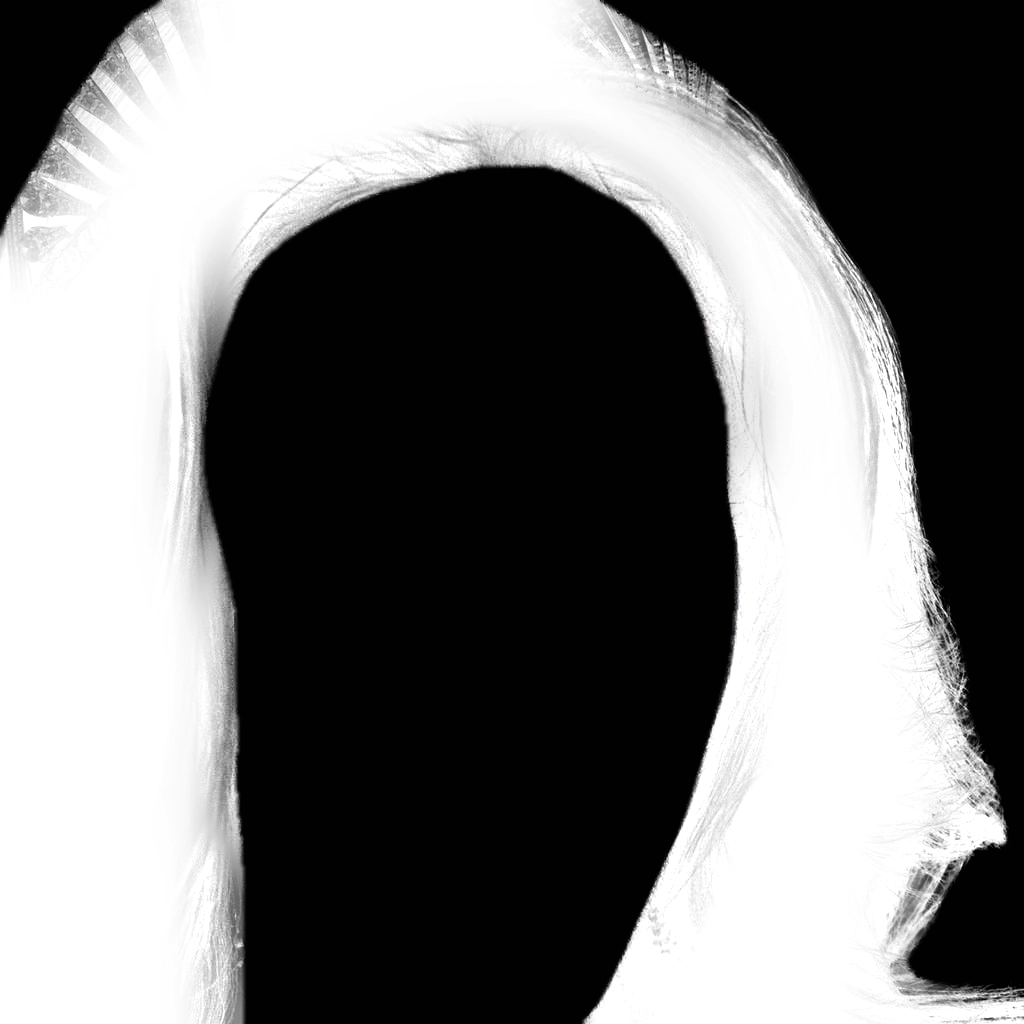

In [17]:
if mask_paths:
    with Image.open(mask_paths[0]) as sample_mask:
        print('Sample mask size:', sample_mask.size)
        display(sample_mask)
else:
    print('No CelebAHairMask-HQ mask files found.')


## Takeaways

- A raw `Hairmony` directory is present in the workspace.
- The currently visible local `Hairmony` content is a large taxonomy CSV, not an obvious image or mask asset tree.
- The taxonomy is already in English and appears rich enough to inform later hairstyle-attribute reasoning.
- `CelebAHairMask-HQ` is also present locally, but it should be treated as a separate companion mask dataset rather than as the same thing as `Hairmony`.
